In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# loading data
labels = pd.read_csv('class.tsv', sep='\t', header=None, names=['label'])
mapping = pd.read_csv('columns.tsv.gz', sep='\t', skiprows=18)
data = pd.read_csv('filtered.tsv.gz', sep='\t')

# column picking
data.columns = data.columns.astype(str).str.strip()
mapping['GeneSymbol'] = mapping['GeneSymbol'].astype(str).str.strip()
mapping['ID'] = mapping['ID'].astype(str).str.strip()

# target id's
xbp1_id = '4404'
gata_row = mapping[mapping['GeneSymbol'] == 'GATA3']
if gata_row.empty:
    print("Warning: GATA3 not found. Checking for alternative names...")
    gata_row = mapping[mapping['GeneSymbol'].str.contains('GATA3', na=False)]

gata3_id = gata_row['ID'].values[0]

# creating dataframe
df = pd.DataFrame({
    'XBP1': data[xbp1_id],
    'GATA3': data[gata3_id],
    'label': labels['label']
})

print(f"Successfully matched XBP1 (ID: {xbp1_id}) and GATA3 (ID: {gata3_id})!")

Successfully matched XBP1 (ID: 4404) and GATA3 (ID: 4359)!


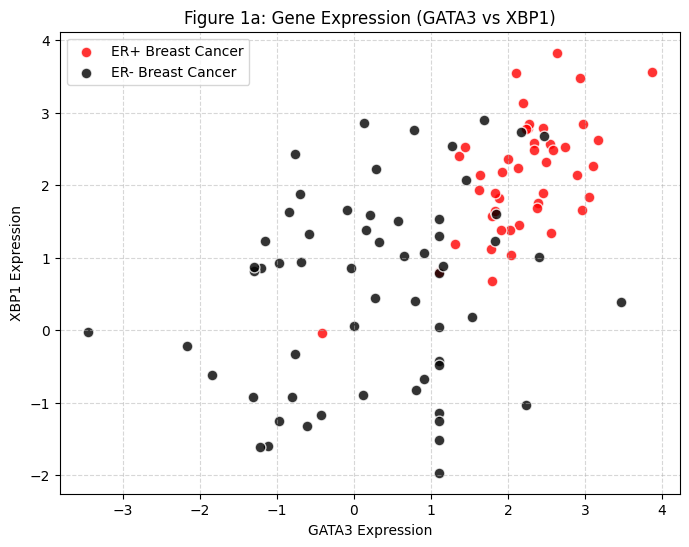

In [8]:
plt.figure(figsize=(8, 6))

# defining colors and labels
# 1 = ER+ (Red), 0 = ER- (Black)
colors = {1: 'red', 0: 'black'}
names = {1: 'ER+ Breast Cancer', 0: 'ER- Breast Cancer'}

for status in [1, 0]:
    subset = df[df['label'] == status]
    plt.scatter(subset['GATA3'], subset['XBP1'],
                c=colors[status], label=names[status],
                edgecolors='white', s=60, alpha=0.8)

plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Figure 1a: Gene Expression (GATA3 vs XBP1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

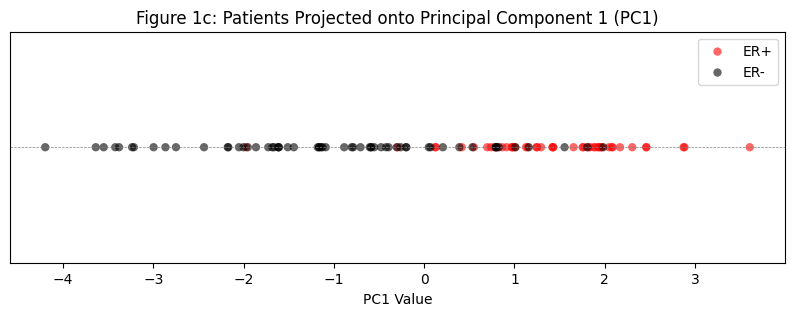

PC1 explains 77.92% of the variance between these two genes.


In [9]:
# running pca
X = df[['GATA3', 'XBP1']]
pca = PCA(n_components=1)
df['PC1'] = pca.fit_transform(X)

# plotting the 1D Projection
plt.figure(figsize=(10, 3))
for status, color, label in [(1, 'red', 'ER+'), (0, 'black', 'ER-')]:
    subset = df[df['label'] == status]
    plt.scatter(subset['PC1'], [0] * len(subset),
                c=color, label=label, alpha=0.6, edgecolors='none')

plt.title('Figure 1c: Patients Projected onto Principal Component 1 (PC1)')
plt.xlabel('PC1 Value')
plt.yticks([])
plt.legend()
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.show()

# printing the variance
print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of the variance between these two genes.")